In [162]:
import pandas as pd
import json
import pprint

In [163]:
def load_papers(filepath):
    """Load papers with concepts from JSON file."""
    with open(filepath, "r") as f:
        return json.load(f)

In [164]:
json_path = "sirt6_paper_corpus/sirt6_paper_abstracts.json"
loaded_papers = load_papers(json_path)

In [165]:
loaded_papers.get('Effects of Nicotinamide Adenine Dinucleotide on Older Patients with Heart Failure')

'Background: Heart failure (HF) is the main cause of death in middle-aged and older people and is characterized by high morbidity, high mortality, a high rehospitalization rate, and many high-risk groups. Nicotinamide adenine dinucleotide (NAD+) is widely present in the mitochondria of cardiomyocytes and maintains the redox balance in the body, which can effectively treat HF. We sought to evaluate whether NAD+ therapy has some clinical efficacy in patients with HF. Methods: Based on using conventional drugs to treat HF, patients (n = 60) were randomized 1:1 to saline and 50 mg NAD+ with 50 mL of normal saline for 7 days. The baseline characteristics of patients before and after treatment and cardiac function (N-terminal pro B-type natriuretic peptide (NT-proBNP) level and left ventricular ejection fraction (LVEF) value) were analyzed. Serological analysis (sirtuin-1 (SIRT1), sirtuin-3 (SIRT3), sirtuin-6 (SIRT6), reactive oxygen species (ROS), and endothelin) was also performed. Results

## Core cleaning

In [166]:
import re
import html
import unicodedata
from typing import Dict, List
from langdetect import detect, LangDetectException

In [ ]:
STRUCTURE_WORDS = [
    "abstract",
    "graphical abstract",
    "aims", 
    "Purpose",
    "Results:",
    "conclusion", 
    "conclusions",
    "objectives",
    "background", 
    "introduction", 
    "materials and methods", 
    "summary", 
    "BACKGROUND AND PURPOSE", 
    "EXPERIMENTAL APPROACH", 
    "IMPORTANCE",
    "KEY RESULTS", 
    "AND IMPLICATIONS" , 
    "Citation information", 
    "Citation format"
]

In [168]:
text = loaded_papers.get('Abstract 1984: Crosstalk between sirtuins and TGF-β signaling suppresses liver cancer')

In [169]:
STRUCTURE_PATTERN = re.compile(
    r"\b(" + "|".join(STRUCTURE_WORDS) + r")\b\s*:?",
    flags=re.IGNORECASE
)

In [170]:
def normalize_spaces(text):
    # 1. Fix spaces inside brackets/parentheses
    # "( p=1)" -> "(p=1)" and " ]" -> "]"
    text = re.sub(r'\(\s+', '(', text)  # Space after (
    text = re.sub(r'\s+\)', ')', text)  # Space before )
    text = re.sub(r'\[\s+', '[', text)  # Space after [
    text = re.sub(r'\s+\]', ']', text)  # Space before ]

    # 2. Fix spaces around mathematical operators (Optional but recommended)
    # "p < 0.05" -> "p<0.05" OR ensure consistent spacing "p < 0.05"
    # Here we standardize to "p<0.05" (no spaces) as it is common in scientific text
    text = re.sub(r'\s*<\s*', '<', text)
    text = re.sub(r'\s*>\s*', '>', text)
    text = re.sub(r'\s*=\s*', '=', text)
    text = re.sub(r'\s*&lt;\s*', '<', text)

    # 3. Collapse multiple spaces into a single space everywhere else
    # "The    result   is" -> "The result is"
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

In [171]:
def filter_by_language(text, target_lang='en'):
    """
    Keeps only the sentences that match the target language.
    This removes duplicate translations in other languages.
    """

    # 1. Split text into sentences using regex
    # This splits by period, question mark, or exclamation point followed by space
    sentences = re.split(r'(?<=[.!?])\s+', text)
    
    filtered_sentences = []
    
    for sent in sentences:
        # Skip empty sentences or very short ones (detection is unreliable on short strings)
        if len(sent) < 20:
            # If it's extremely short, we keep it to avoid losing titles/headers
            # unless you are sure they are noise.
            filtered_sentences.append(sent)
            continue

        try:
            # Detect the language of the sentence
            detected_lang = detect(sent)
            
            # If it matches our target language, keep it
            if detected_lang == target_lang:
                filtered_sentences.append(sent)
                
        except LangDetectException:
            # If detection fails (e.g., mostly numbers/symbols), keep it just in case
            filtered_sentences.append(sent)

    # 2. Rejoin the sentences
    return " ".join(filtered_sentences).strip()

In [172]:
def remove_citations(text: str) -> str:

    # 1. Remove Bullet points and Newlines
    text = text.replace('•', ' ').replace('\n', '')
    text = text.replace('<div>', '').replace('</div>', '').replace('</p>', '').replace('<p>', '')
    text = text.replace('</sup>', '').replace('<sup>', '').replace('<em>', '').replace('</em>', '').replace('<sub>', '').replace('</sub>', '') 
    text = text.replace('<b>', '').replace('</b>', '').replace('<i>', '').replace('</i>', '')  
    text = text.replace('&kappa;', '').replace('&alpha;', '').replace('&beta;', '').replace('&rsquo;', '')  

    # A. Remove DOI lines and references ending in DOI
    # Matches: "doi: 10.1158/0008-5472.CAN-12-1943"
    text = re.sub(r'\bdoi:\s*10\.\d+/[^\s]+', '', text, flags=re.IGNORECASE)

    # B. Remove "Published OnlineFirst" and similar publication status lines
    # Matches: "Published OnlineFirst December 13, 2012"
    text = re.sub(r'Published OnlineFirst.*$', '', text, flags=re.DOTALL | re.IGNORECASE)
    text = re.sub(r'\(Epub ahead of print\)', '', text)

    # C. Remove Loose References (Journal Year;Volume:Pages)
    # Matches: "Mol Cancer Ther 2013;12(11 Suppl):B109." or "Blood 2016;128:12-20."
    # Pattern: Capitalized words (Journal) + 4-digit Year + Volume/Page info
    text = re.sub(r'\b(?:[A-Z][a-z]+(?: [A-Z][a-z]+)*) \d{4}[;:]\s*[\d\w\(\)\.\-:]+\.?', '', text)

    # D. Remove Parenthesized Citations (In-text citations)
    # Matches: "(Qu et al. in Int J Oncol 50(5):1683–92, 2017)", "(Sebastian et al., 2012; Wang et al., 2012)"
    # Logic: Find text inside (...) that contains citation keywords
    citation_keywords = r'et al\.|et al|doi|Vol\.|pp\.|Suppl|In Press|\d{4};|\d{4},'
    text = re.sub(r'\([^)]*(?:' + citation_keywords + r')[^)]*\)', '', text)

    # E. Remove Lists of Authors (Common in reference lists)
    # Matches: "Liz M. Garcia-Peterson, Mary A. Ndiaye, Chandra K. Singh,"
    # This looks for 3 or more consecutive "Name, Name, Name," patterns.
    author_pattern = r'(?:[A-Z][a-z]+(?: [A-Z]\.)?(?: [A-Z][a-z]+-)?[A-Z][a-z]+, )'
    if len(re.findall(author_pattern, text)) >= 2:
        text = re.sub(author_pattern + '{2,}', '', text)

    # F. Remove Truncated names at end of string
    # Matches: "Jee-" at the end of a document
    text = re.sub(r'\b[A-Z][a-z]+-\s*$', '', text)


    # 1. Remove everything starting with "In: Proceedings" or "In: Abstract"
    # Matches: "In: Proceedings of the AACR Special Conference..."
    text = re.sub(r'\s+In:\s+(?:Proceedings|Conference|Abstract|Poster).*$', '', text, flags=re.IGNORECASE | re.DOTALL)

    # 2. Remove location/publisher patterns common in citations
    # Matches: "Philadelphia (PA): AACR" or "New York (NY): Elsevier"
    text = re.sub(r'\s+[A-Z][a-z]+(?:\s[A-Z])?\s\([A-Z]{2}\):\s[^.]+\.?$', '', text)

    # 3. Remove "Suppl): nr XXX" patterns (Supplement references)
    # Matches: "Suppl): nr PR12"
    text = re.sub(r'\s+Suppl\):\s*nr\s*\w+.*$', '', text, flags=re.IGNORECASE)

    text = filter_by_language(text)

    text = re.sub(
        r'\b(?:[A-Z][a-z.]+(?:\s+[A-Z][a-z.]+)*)\s+(?:\d{4}[;:]|\d+\:\d+)\s*[\d\w\(\)\.\-:]+\.?', 
        '', 
        text
    )

    # 2. Remove "Equal Contribution" footers (Part of Pattern 2)
    # Matches: "*These authors contributed equally to this work"
    text = re.sub(r'\*These authors contributed equally.*', '', text, flags=re.IGNORECASE)

    # 3. Remove Author/Affiliation Blocks (Pattern 2)
    # Matches: "Lei Ouyang,1,* Liang Yi,1,* ... Department of ... China"
    # Logic: Finds sequences of "Name, 1," repeated at least twice, followed by Institution keywords
    # This prevents accidentally deleting normal sentences that mention one author.
    text = re.sub(
        r'(?:[A-Z][a-z\-]+(?: [A-Z]\.)?,\s*\d+[,*]\s*){2,}.*?(?:Department|Institute|University|Affiliated|People\'s Republic of China|Correspondence).*', 
        '', 
        text, 
        flags=re.DOTALL
    )

    # G. Cleanup spacing artifacts created by removals
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()

    return text


In [173]:
def remove_title_from_text(text, title):
    """
    Removes the title string from the beginning of the abstract text.
    Also removes any immediate punctuation (.,:, -) following the title.
    """
    if not isinstance(text, str) or not isinstance(title, str):
        return text
    
    if not title.strip():
        return text

    # 1. Escape the title to ensure special chars (like +, ?, (, )) don't break the regex
    # 2. Anchor to the start of the string (^)
    # 3. Match optional trailing punctuation/spaces ([\.:,\-]*) to catch "Title:" or "Title -"
    pattern = re.compile(r'^' + re.escape(title) + r'[\s\.:,\-]*')
    
    # Substitute the match with an empty string
    cleaned_text = pattern.sub('', text)
    
    # Return stripped text to remove leading whitespace left behind
    return cleaned_text.strip()

In [174]:
def clean_abstract(text: str, title: str) -> str:
    if not isinstance(text, str):
        return ""

    # 0. Remove title from abstract text
    text = remove_title_from_text(text, title)

    # 1. Normalize unicode (important for biomedical text)
    text = unicodedata.normalize("NFKC", text)

    # 2. Remove XML / HTML tags and anything inside <>
    text = re.sub(r"<[^>]+>", " ", text)

    # 3. Decode HTML entities (e.g., &amp; -> &, &lt; -> <)
    text = html.unescape(text)

    # 4. Remove square & curly brackets
    text = re.sub(r"[\[\]\{\}]", " ", text)

    # Req 4: Remove everything after "Trial registration:"
    # The DOTALL flag ensures it removes across newlines until the end
    text = re.sub(r'\bTrial registration:.*$', '', text, flags=re.IGNORECASE | re.DOTALL)

    # Req 4: Remove everything after "Trial registration:"
    # The DOTALL flag ensures it removes across newlines until the end
    text = re.sub(r'\bClinical Trial Registration:.*$', '', text, flags=re.IGNORECASE | re.DOTALL)
    
    # Req 5 & 1: Remove everything after "Disclosure"
    # This effectively removes the patterns in Req 1 (e.g., "Disclosures Gordon: ...")
    # because they start with this keyword.
    text = re.sub(r'\bDisclosure.*$', '', text, flags=re.IGNORECASE | re.DOTALL)

     # Req 5 & 1: Remove everything after "References"
    # This effectively removes the patterns in Req 1 (e.g., "Disclosures Gordon: ...")
    # because they start with this keyword.
    text = re.sub(r'\bReferences.*$', '', text, flags=re.IGNORECASE | re.DOTALL)

    # Req 6: Remove everything after "Conflict of interest statement"
    # The DOTALL flag ensures it removes across newlines until the end
    text = re.sub(r'\bConflict of interest statement.*$', '', text, flags=re.IGNORECASE | re.DOTALL)

    # Req 7: Remove everything after "Grant Funding Source"
    # The DOTALL flag ensures it removes across newlines until the end
    text = re.sub(r'\bGrant Funding Source.*$', '', text, flags=re.IGNORECASE | re.DOTALL)

    # Req 7: Remove everything after "SIGNIFICANCE STATEMENT:"
    # The DOTALL flag ensures it removes across newlines until the end
    text = re.sub(r'\bSIGNIFICANCE STATEMENT:.*$', '', text, flags=re.IGNORECASE | re.DOTALL)

    # Req 7: Remove everything after "SIGNIFICANCE STATEMENT:"
    # The DOTALL flag ensures it removes across newlines until the end
    text = re.sub(r'\bSupport or Funding Information.*$', '', text, flags=re.IGNORECASE | re.DOTALL)

    # Req 2: Remove specific unstructured references
    # Pattern A: Matches "Du et al, Science, Vol. 334, ... 2011"
    # Looks for "Name et al, Name, Vol." or "Name et al, Name, Year"
    text = re.sub(r'\.?\s*[A-Z][a-z]+ et al\, [A-Z][a-z]+, Vol\..*?(\d{4}|pages|pp\.)', '', text, flags=re.DOTALL)
    
    # Pattern B: Matches "2. Jiang et al, Nature, 496, 110 113"
    # Looks for "Number. Name et al ... Year"
    text = re.sub(r'\.?\s*\d+\s+[A-Z][a-z]+ et al\,.*?\d{4}', '', text, flags=re.DOTALL)

    # 5. Remove structured abstract headers
    text = STRUCTURE_PATTERN.sub(" ", text)

    # 6. Merge multiple paragraphs into one
    text = re.sub(r"\s*\n+\s*", " ", text)

    # 7. Remove excessive punctuation (keep . , ; :)
    #text = re.sub(r"[^\w\s\.,;:]", " ", text)
    text = re.sub(r'([!?])\1+', r'\1', text) 

    # 8. Collapse multiple spaces
    text = re.sub(r"\s+", " ", text)

    # 9. Remove citations in parentheses (e.g., (Smith et al., 2020))
    # Note: Use with caution. This regex looks for standard name-year patterns.
    # If your abstracts use parentheses for other math/data, this might be too aggressive.
    text = re.sub(r'\([A-Z][a-z]+ et al\., \d{4}\)', ' ', text)

    # 10. Remove URLs/DOIs
    text = re.sub(r'https?://\S+|www\.\S+|doi:\S+', ' ', text)

    # 11. Remove email addresses
    text = re.sub(r'\S*@\S*\s?', ' ', text)

    # 12. Remove specific artifacts common in PDF/excel scrapes
    # e.g., "Figure 1", "Table II", "© 2023"
    text = re.sub(r'Figure \d+|Table \d+|© \d{4}', ' ', text, flags=re.IGNORECASE)

    # 13. Remove citations
    text = remove_citations(text)

    # Req 3: Fix spacing artifacts " ." -> "." and " ," -> ","
    text = re.sub(r'\s+\.', '.', text)
    text = re.sub(r'\s+,', ',', text)

    text = normalize_spaces(text)
    text = re.sub(r'NAD\s*\+', 'NAD+', text)
    text = re.sub(r'SIRT\s*[-\s]\s*([1-7])', r'SIRT\1', text)

    return text.strip()

In [175]:
def clean_titles(text: str) -> str:
    # 1. Normalize unicode (important for biomedical text)
    text = unicodedata.normalize("NFKC", text)

    # 2. Remove XML / HTML tags and anything inside <>
    text = re.sub(r"<[^>]+>", " ", text)

    # 3. Decode HTML entities (e.g., &amp; -> &, &lt; -> <)
    text = html.unescape(text)

    # 4. Remove square & curly brackets
    text = re.sub(r"[\[\]\{\}]", " ", text)

    # 7. Remove excessive punctuation (keep . , ; :)
    #text = re.sub(r"[^\w\s\.,;:]", " ", text)
    text = re.sub(r'([!?])\1+', r'\1', text) 

    # 8. Collapse multiple spaces
    text = re.sub(r"\s+", " ", text)

    # 9. Remove citations in parentheses (e.g., (Smith et al., 2020))
    # Note: Use with caution. This regex looks for standard name-year patterns.
    # If your abstracts use parentheses for other math/data, this might be too aggressive.
    #text = re.sub(r'\([A-Z][a-z]+ et al\., \d{4}\)', ' ', text)

    # 10. Remove URLs/DOIs
    #text = re.sub(r'https?://\S+|www\.\S+|doi:\S+', ' ', text)

    # 11. Remove email addresses
    #text = re.sub(r'\S*@\S*\s?', ' ', text)

    # 12. Remove specific artifacts common in PDF/excel scrapes
    # e.g., "Figure 1", "Table II", "© 2023"
    #text = re.sub(r'Figure \d+|Table \d+|© \d{4}', ' ', text, flags=re.IGNORECASE)

    # 13. Remove citations
    #text = remove_citations(text)

    text = text.replace('<b>', '').replace('</b>', '').replace('<i>', '').replace('</i>', '').replace('<p>', '').replace('</p>', '')    
    text = text.replace('&nbsp', ' ')

    # Req 3: Fix spacing artifacts " ." -> "." and " ," -> ","
    text = re.sub(r'\s+\.', '.', text)
    text = re.sub(r'\s+,', ',', text)


    return text.strip()

In [176]:
clean_titles('Quinazolinedione SIRT6 inhibitors sensitize cancer cells to chemotherapeutics')

'Quinazolinedione SIRT6 inhibitors sensitize cancer cells to chemotherapeutics'

In [177]:
loaded_papers.get('Quinazolinedione SIRT6 inhibitors sensitize cancer cells to chemotherapeutics')

"The NAD(+)-dependent sirtuin SIRT6 is highly expressed in human breast, prostate, and skin cancer where it mediates resistance to cytotoxic agents and prevents differentiation. Thus, SIRT6 is an attractive target for the development of new anticancer agents to be used alone or in combination with chemo- or radiotherapy. Here we report on the identification of novel quinazolinedione compounds with inhibitory activity on SIRT6. As predicted based on SIRT6's biological functions, the identified new SIRT6 inhibitors increase histone H3 lysine 9 acetylation, reduce TNF-α production and increase glucose uptake in cultured cells. In addition, these compounds exacerbate DNA damage and cell death in response to the PARP inhibitor olaparib in BRCA2-deficient Capan-1 cells and cooperate with gemcitabine to the killing of pancreatic cancer cells. In conclusion, new SIRT6 inhibitors with a quinazolinedione-based structure have been identified which are active in cells and could potentially find ap

In [178]:
text = loaded_papers.get("3-iodothyronamine as a potential anti-tumor compound")

In [179]:
STRUCTURE_PATTERN.sub(" ", text)

'  3-iodothyronamine (T1AM) is an endogenous messenger chemically related to thyroid hormone, which produces significant effects on energy metabolism and modulates mammalian sirtuin expression. In particular, subchronic T1AM administration was reported to increase the expression of mammalian sirtuin 6 (SIRT6), which has a pro-apoptotic role. Therefore in the present study we evaluated the effects of T1AM on viability and proliferation of cancer and non cancer cell lines.&#13;\\nMethods: Four cell lines (HepG2, liver carcinoma; H9c2, cardiomyoblasts; Caco-2, colon carcinoma; and WI-38, lung fibroblasts) were cultured for 24/48h in the presence or absence of different concentrations of exogenous T1AM (0.1-1-10 \uf06dM). Cell viability was determined by crystal violet staining and transmission electron microscopy (TEM) analysis was performed. To evaluate changes in SIRT 6 gene expression, cells were incubated with the same concentrations of T1AM, and gene expression was assessed by real-t

In [180]:
len(str(loaded_papers.get('Sirt6 regulates dendritic cell differentiation, maturation, and function')).split())

204

(0.0, 500.0)

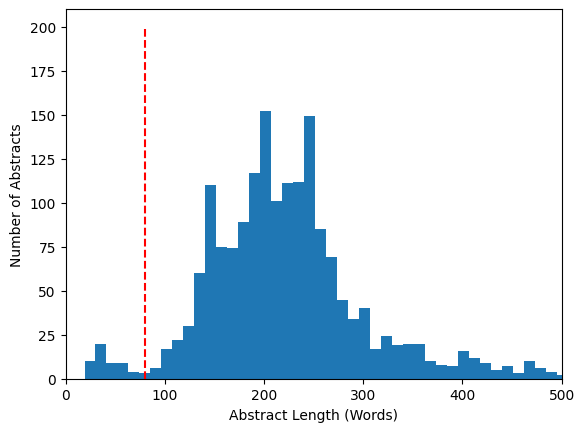

In [181]:
abstract_lengths = []
for _, abstract_i in loaded_papers.items():
    abstract_lengths.append(len(str(abstract_i).split()))

import matplotlib.pyplot as plt
plt.hist(abstract_lengths, bins=150)
plt.xlabel("Abstract Length (Words)")
plt.ylabel("Number of Abstracts")
plt.vlines(80, 0, 200, colors='r', linestyles='dashed', label='80 words')
plt.xlim(0, 500)

In [182]:
title_lengths = []
for title_i, _ in loaded_papers.items():
    if len(str(title_i).split()) < 2:
        print(title_i)

(0.0, 40.0)

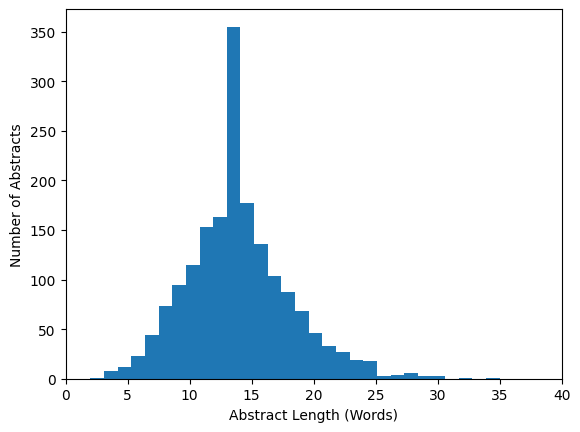

In [183]:
title_lengths = []
for title_i, _ in loaded_papers.items():
    title_lengths.append(len(str(title_i).split()))

import matplotlib.pyplot as plt
plt.hist(title_lengths, bins=30)
plt.xlabel("Abstract Length (Words)")
plt.ylabel("Number of Abstracts")
plt.vlines(80, 0, 200, colors='r', linestyles='dashed', label='80 words')
plt.xlim(0, 40)

In [184]:
def prepare_bertopic_corpus(abstract_dict: Dict[str, str]):
    titles = []
    documents = []

    for title, abstract in abstract_dict.items():
        clean_text = clean_abstract(abstract, title)
        #clean_title = clean_abstract(title)
        if len(clean_text.split()) < 80:
            # Skip very short / junk abstracts
            continue
        titles.append(title)
        documents.append(clean_text)

    return documents, titles

In [185]:
docs, titles = prepare_bertopic_corpus(loaded_papers)

In [186]:
len(titles)

1711

In [187]:
docs

['The Sir2 histone deacetylase functions as a chromatin silencer to regulate recombination, genomic stability, and aging in budding yeast. Seven mammalian Sir2 homologs have been identified (SIRT1-SIRT7), and it has been speculated that some may have similar functions to Sir2. Here, we demonstrate that SIRT6 is a nuclear, chromatin-associated protein that promotes resistance to DNA damage and suppresses genomic instability in mouse cells, in association with a role in base excision repair (BER). SIRT6-deficient mice are small and at 2-3 weeks of age develop abnormalities that include profound lymphopenia, loss of subcutaneous fat, lordokyphosis, and severe metabolic defects, eventually dying at about 4 weeks. We conclude that one function of SIRT6 is to promote normal DNA repair, and that SIRT6 loss leads to abnormalities in mice that overlap with aging-associated degenerative processes.',
 'The Sir2 deacetylase regulates chromatin silencing and lifespan in Saccharomyces cerevisiae. In

## Deduplication of near-identical abstracts

In [188]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [189]:
def remove_near_duplicates(docs, titles, threshold=0.95):
    vec = TfidfVectorizer(stop_words="english").fit_transform(docs)
    sim = cosine_similarity(vec)
    keep = []
    for i in range(len(docs)):
        if not any(sim[i][j] > threshold for j in keep):
            keep.append(i)
    return [docs[i] for i in keep], [titles[i] for i in keep]

In [190]:
deduplicated_docs, deduplicated_titles = remove_near_duplicates(docs, titles)

In [191]:
print(len(deduplicated_docs))
print(len(deduplicated_titles))

1648
1648


In [192]:
len(docs)

1711

In [193]:
deduplicated_docs

['The Sir2 histone deacetylase functions as a chromatin silencer to regulate recombination, genomic stability, and aging in budding yeast. Seven mammalian Sir2 homologs have been identified (SIRT1-SIRT7), and it has been speculated that some may have similar functions to Sir2. Here, we demonstrate that SIRT6 is a nuclear, chromatin-associated protein that promotes resistance to DNA damage and suppresses genomic instability in mouse cells, in association with a role in base excision repair (BER). SIRT6-deficient mice are small and at 2-3 weeks of age develop abnormalities that include profound lymphopenia, loss of subcutaneous fat, lordokyphosis, and severe metabolic defects, eventually dying at about 4 weeks. We conclude that one function of SIRT6 is to promote normal DNA repair, and that SIRT6 loss leads to abnormalities in mice that overlap with aging-associated degenerative processes.',
 'The Sir2 deacetylase regulates chromatin silencing and lifespan in Saccharomyces cerevisiae. In

## Add publication years

In [194]:
unfiltered_corpus = pd.read_csv("sirt6_paper_corpus/SIRT6_openalex_papers_recovered_abstracts.csv")

In [195]:
publication_year = unfiltered_corpus.loc[unfiltered_corpus.title.isin(deduplicated_titles)].publication_year.values.astype('str')

In [196]:
from datetime import datetime

## Clean titles

In [197]:
deduplicated_titles = [clean_titles(title) for title in deduplicated_titles]

In [198]:
len(deduplicated_titles)

1648

Prepare list with dates and 

In [199]:
format_specifier = "%Y"

datetime_object = [datetime.strptime(year, format_specifier) for year in publication_year]

In [200]:
len(deduplicated_titles), len(deduplicated_docs), len(datetime_object),

(1648, 1648, 1648)

In [201]:
abstract_corpus = pd.DataFrame.from_dict({"titles": deduplicated_titles, "abstracts": deduplicated_docs, "year": datetime_object})

In [202]:
abstract_corpus.to_csv("sirt6_paper_corpus/SIRT6_abstract_corpus.csv", index = False)